Creating VAE model...
Training VAE...
Epoch 1/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - kl_loss: 26.0346 - loss: 366.6518 - reconstruction_loss: 340.6172
Epoch 2/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 12.5197 - loss: 209.1801 - reconstruction_loss: 196.6604
Epoch 3/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 7.6421 - loss: 195.3524 - reconstruction_loss: 187.7102
Epoch 4/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.0647 - loss: 190.3181 - reconstruction_loss: 184.2534
Epoch 5/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 5.4922 - loss: 186.5120 - reconstruction_loss: 181.0198
Epoch 6/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.4259 - loss: 180.0264 - reconstruction_loss: 174.6005
Epoch 7/7
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 5.1669 - loss: 175.3628 - reconstruction_loss: 170.1959

Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step


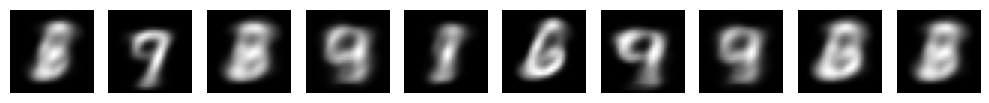

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Flatten, Reshape, Layer
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess MNIST data
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 28, 28, 1))

# Network parameters
input_shape = (28, 28, 1)
batch_size = 128
latent_dim = 2
intermediate_dim = 512
epochs = 7

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        z_mean = z_mean + tf.exp(0.5 * z_log_var) * epsilon
        return z_mean

# Encoder
encoder_inputs = Input(shape=input_shape)
x = Flatten()(encoder_inputs)
x = Dense(intermediate_dim, activation='relu')(x)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
decoder_inputs = Input(shape=(latent_dim,))
x = Dense(intermediate_dim, activation='relu')(decoder_inputs)
x = Dense(784, activation='sigmoid')(x)
decoder_outputs = Reshape((28, 28, 1))(x)
decoder = Model(decoder_inputs, decoder_outputs, name='decoder')

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name='total_loss')
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = tf.keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Encoder output
            z_mean, z_log_var, z = self.encoder(data)
            # Reconstruction
            reconstruction = self.decoder(z)

            # Flatten input and reconstruction for binary crossentropy
            flat_data = tf.reshape(data, (-1, 784))
            flat_reconstruction = tf.reshape(reconstruction, (-1, 784))

            # Reconstruction loss (fixed axis handling)
            reconstruction_loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(
                    flat_data,
                    flat_reconstruction
                )
            ) * 784

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result()
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

# Create and compile VAE
def create_and_compile_vae(encoder, decoder):
  print("Creating VAE model...")
  vae = VAE(encoder, decoder)
  vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))
  return vae


def generate_digits(decoder, n=10):
    """Generate n new digits using the decoder"""
    z_sample = np.random.normal(size=(n, latent_dim))
    x_decoded = decoder.predict(z_sample)
    return x_decoded

# To visualize the generated digits
def plotDigits(digits):
  plt.figure(figsize=(10, 2))
  for i in range(10):
      plt.subplot(1, 10, i + 1)
      plt.imshow(digits[i].reshape(28, 28), cmap='gray')
      plt.axis('off')
  plt.tight_layout()
  plt.show()

vae = create_and_compile_vae(encoder, decoder)
# Train VAE
print("Training VAE...")
vae.fit(x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True)

# After training the VAE, you can use it like this:
print("\nGenerating new digits...")
new_digits = generate_digits(decoder, 10)  # Generates 10 new digits
plotDigits(new_digits)  # Plots the generated digits

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


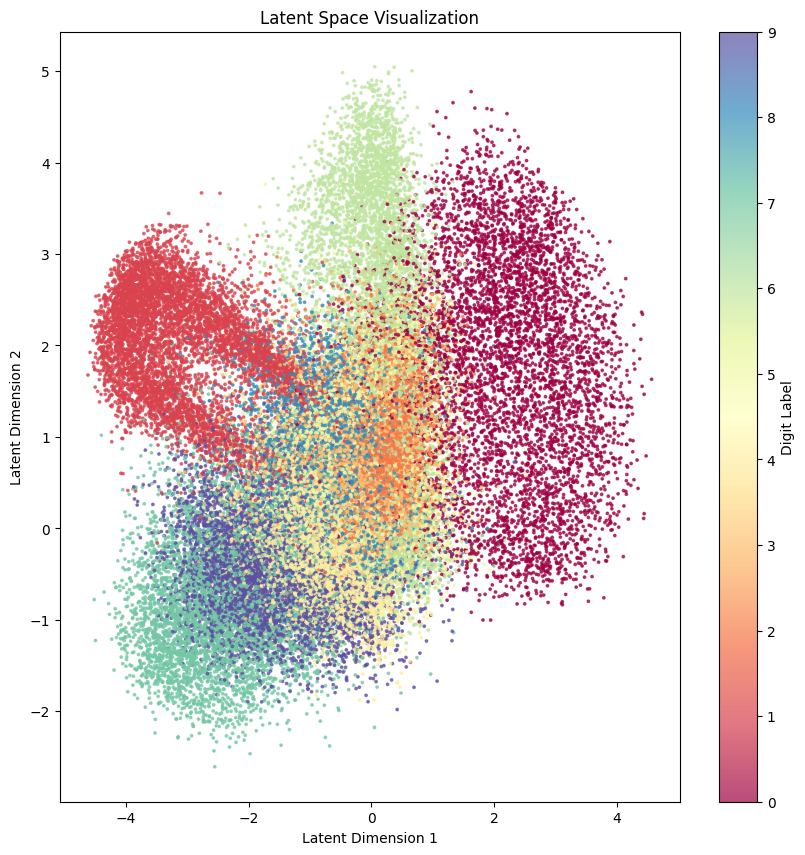

In [5]:
#Task 1: Visualise the latent space
import matplotlib as mpl
def visualize_latent_space(encoder, x_train, y_train):
    z_mean, _, _ = encoder.predict(x_train)

    cmap = mpl.colormaps["Spectral"] # Use a distinct colormap for categories
    plt.figure(figsize=(10, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_train, cmap=cmap, s=3, alpha=0.7)
    plt.colorbar(label='Digit Label') # Add a colorbar to indicate the mapping
    plt.title('Latent Space Visualization')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.show()

visualize_latent_space(encoder, x_train, y_train)

Creating VAE model...
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


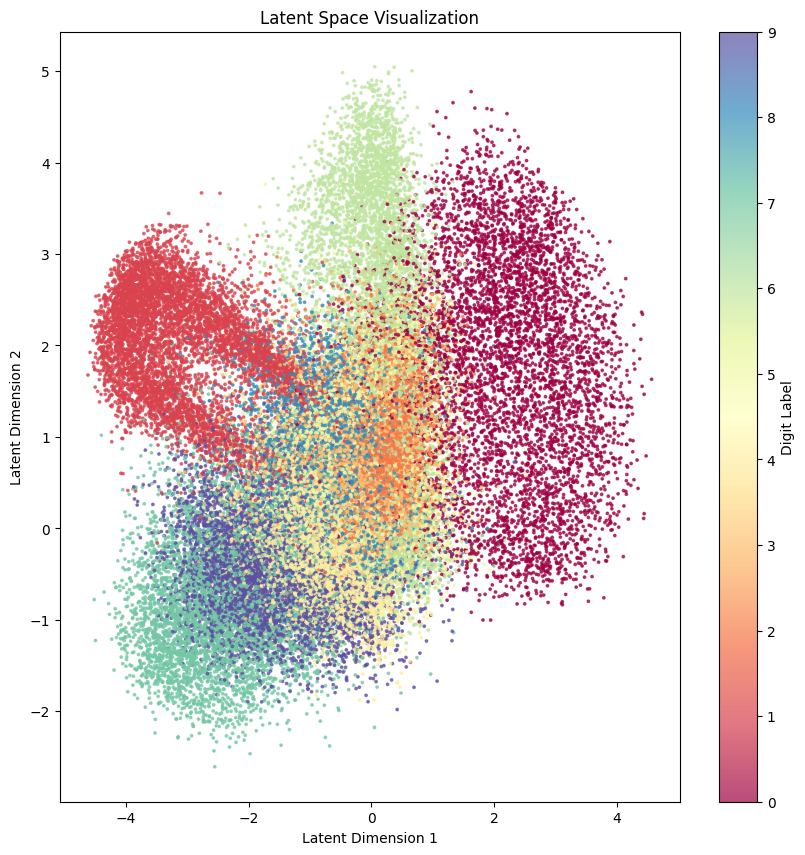

Training VAE...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - kl_loss: 5.0042 - loss: 172.7592 - reconstruction_loss: 167.7550
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.9075 - loss: 171.1620 - reconstruction_loss: 166.2545
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8463 - loss: 169.6410 - reconstruction_loss: 164.7946
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.8131 - loss: 169.1025 - reconstruction_loss: 164.2894
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.8063 - loss: 168.1629 - reconstruction_loss: 163.3566

Generating new digits...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


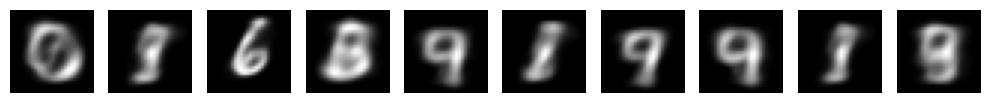

Creating VAE model...
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


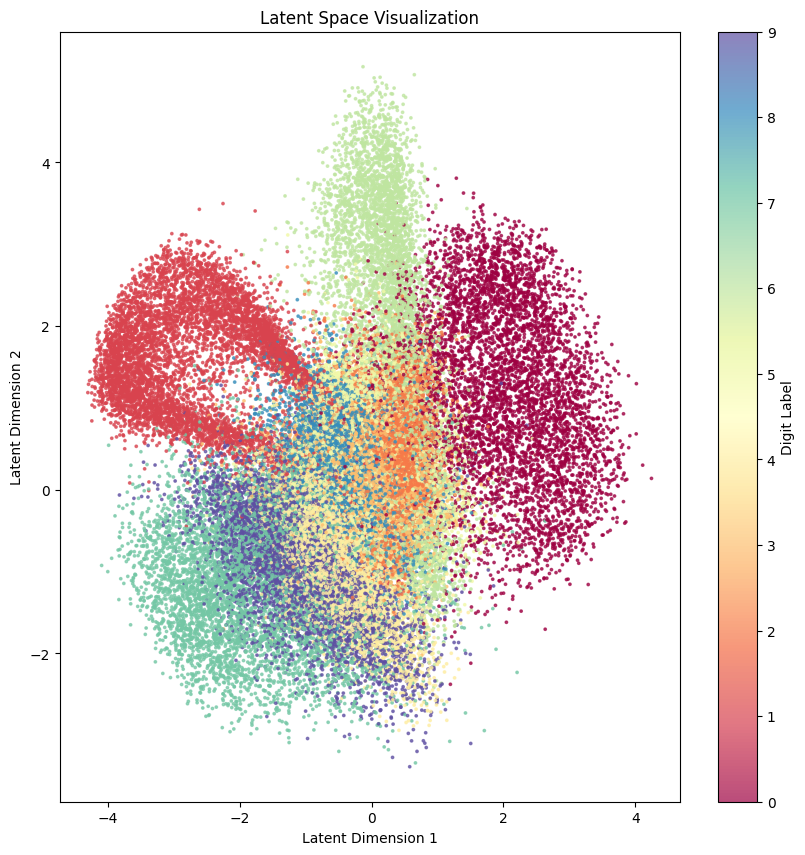

Training VAE...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - kl_loss: 4.7958 - loss: 167.5635 - reconstruction_loss: 162.7677
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8097 - loss: 166.6999 - reconstruction_loss: 161.8902
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.8277 - loss: 166.5471 - reconstruction_loss: 161.7193
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8527 - loss: 165.9811 - reconstruction_loss: 161.1285
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.8823 - loss: 165.1383 - reconstruction_loss: 160.2560
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 4.8996 - loss: 164.8599 - reconstruction_loss: 159.9603
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.9226 - loss: 164.7118 - reconstruction_loss: 159.7891
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 4.9297 - loss: 164.4877 - reconstruction_loss: 159.5580
Epoch 9/15
469/469 ━━━━━━━━━━━━━

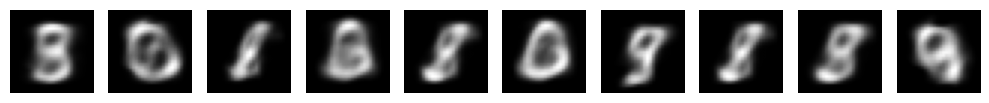

Creating VAE model...
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


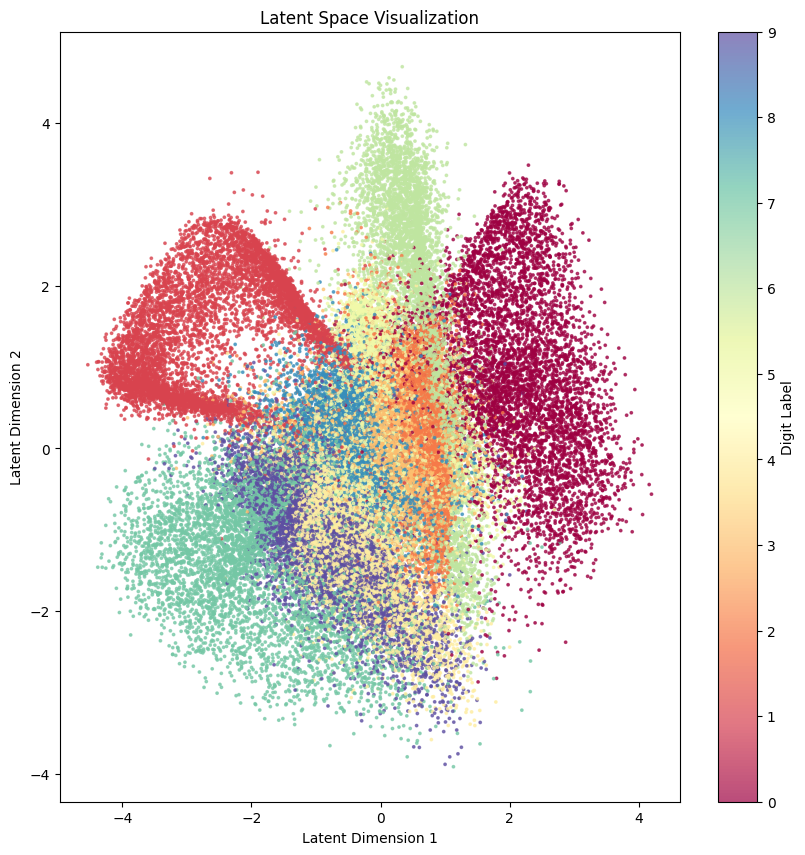

Training VAE...
Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - kl_loss: 5.1915 - loss: 161.6366 - reconstruction_loss: 156.4451
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.2177 - loss: 161.2209 - reconstruction_loss: 156.0032
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.2310 - loss: 160.8476 - reconstruction_loss: 155.6166
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.2863 - loss: 161.0611 - reconstruction_loss: 155.7748
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.2902 - loss: 160.7039 - reconstruction_loss: 155.4137
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3180 - loss: 160.1816 - reconstruction_loss: 154.8637
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3426 - loss: 160.0761 - reconstruction_loss: 154.7335
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 5.3500 - loss: 159.7093 - reconstruction_loss: 154.3594
Epoch 9/30
469/469 ━━━━━━━━━━━━━

In [ ]:
#Task 2: Change epochs
epochs_set = [5, 15, 30]

for epochs in epochs_set:
  vae = create_and_compile_vae(encoder, decoder)

  visualize_latent_space(encoder, x_train, y_train)
  # Train VAE
  print("Training VAE...")
  vae.fit(x_train,
          epochs=epochs,
          batch_size=batch_size,
          shuffle=True)

  # After training the VAE, you can use it like this:
  print("\nGenerating new digits...")
  new_digits = generate_digits(decoder, 10)  # Generates 10 new digits
  plotDigits(new_digits)  # Plots the generated digits